In [1]:
!pip install -q pandas numpy matplotlib seaborn openpyxl scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from IPython.display import display
from google.colab import files

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Uploaded file: seasonal_agriculture_performance_dataset.csv


In [4]:
if file_name.lower().endswith(".csv"):
    df = pd.read_csv(file_name)

elif file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)

else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("DATASET INFORMATION")
print("-------------------")

print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

DATASET INFORMATION
-------------------
Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Missing Values:


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0



Duplicate Rows: 0


In [6]:
# Make a copy
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove completely empty rows
df_clean = df_clean.dropna(how="all")

# Clean column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Data cleaning completed!")
print("Rows after cleaning:", df_clean.shape[0])
print("Columns after cleaning:", df_clean.shape[1])

display(df_clean.head())

Data cleaning completed!
Rows after cleaning: 4000
Columns after cleaning: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
def find_columns(keywords):
    return [
        col for col in df_clean.columns
        if any(word in col.lower() for word in keywords)
    ]

print("Possible Season Columns:")
print(find_columns(["season"]))

print("\nPossible Crop Columns:")
print(find_columns(["crop", "plant", "variety"]))

print("\nPossible Yield Columns:")
print(find_columns(["yield"]))

print("\nPossible Production Columns:")
print(find_columns(["production", "output"]))

print("\nPossible Water Columns:")
print(find_columns(["water", "irrigation"]))

print("\nPossible Rainfall Columns:")
print(find_columns(["rain", "precipitation"]))

print("\nPossible Temperature Columns:")
print(find_columns(["temperature", "temp"]))

print("\nPossible Profit Columns:")
print(find_columns(["profit", "revenue", "income"]))

Possible Season Columns:
['Season']

Possible Crop Columns:
['Crop']

Possible Yield Columns:
['Yield_Tonnes_Ha']

Possible Production Columns:
['Production_Tonnes']

Possible Water Columns:
['Irrigation_Method', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

Possible Rainfall Columns:
['Rainfall_mm']

Possible Temperature Columns:
['Avg_Temperature_C']

Possible Profit Columns:
['Revenue_INR', 'Profit_INR']


In [8]:
# CHANGE THESE NAMES ACCORDING TO YOUR DATASET

season_col = "Season"
yield_col = "Yield_Tonnes_Ha"

# Optional columns — use only if they exist
production_col = None
water_col = None
rainfall_col = None
temperature_col = None
profit_col = None
crop_col = None
region_col = None

In [9]:
required_columns = [season_col, yield_col]

for col in required_columns:
    if col not in df_clean.columns:
        raise ValueError(
            f"Column '{col}' not found. "
            f"Available columns are: {df_clean.columns.tolist()}"
        )

print("Selected columns are valid!")

Selected columns are valid!


In [10]:
numeric_columns = [
    yield_col,
    production_col,
    water_col,
    rainfall_col,
    temperature_col,
    profit_col
]

numeric_columns = [
    col for col in numeric_columns
    if col is not None and col in df_clean.columns
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col], errors="coerce"
    )

print("Numeric columns:", numeric_columns)

Numeric columns: ['Yield_Tonnes_Ha']


In [11]:
display(df_clean[numeric_columns].describe())

,Yield_Tonnes_Ha
count,3968.000000
mean,5.270595
std,13.361398
min,0.300000
25%,1.050000
50%,1.740000
75%,2.840000
max,101.440000


In [12]:
season_yield = (
    df_clean.groupby(season_col)[yield_col]
    .mean()
    .sort_values(ascending=False)
)

display(season_yield)

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


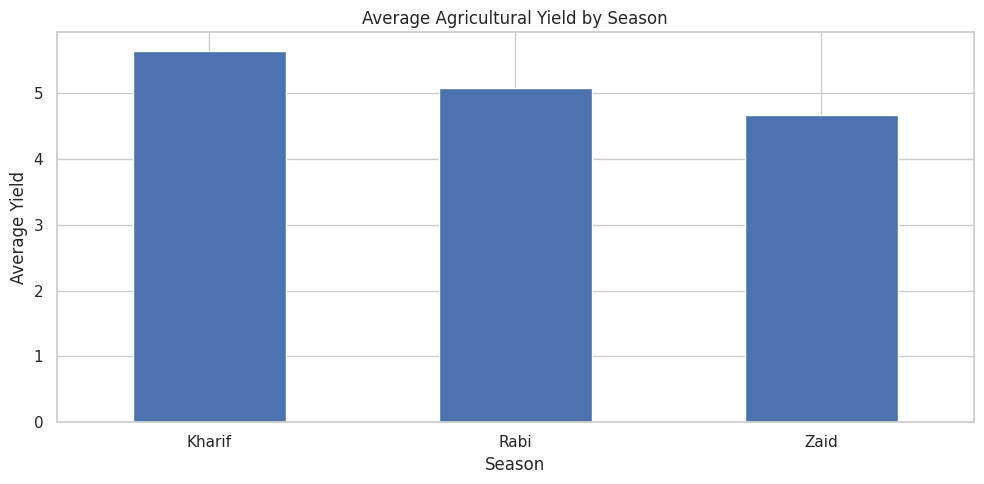

In [13]:
plt.figure(figsize=(10, 5))

season_yield.plot(kind="bar")

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
if production_col is not None and production_col in df_clean.columns:

    season_production = (
        df_clean.groupby(season_col)[production_col]
        .sum()
        .sort_values(ascending=False)
    )

    display(season_production)

else:
    print("Production column not available.")

Production column not available.


In [15]:
if production_col is not None and production_col in df_clean.columns:

    plt.figure(figsize=(10, 5))

    season_production.plot(kind="bar")

    plt.title("Total Agricultural Production by Season")
    plt.xlabel("Season")
    plt.ylabel("Total Production")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [16]:
if water_col is not None and water_col in df_clean.columns:

    season_water = (
        df_clean.groupby(season_col)[water_col]
        .mean()
        .sort_values(ascending=False)
    )

    display(season_water)

else:
    print("Water usage column not available.")

Water usage column not available.


In [17]:
if water_col is not None and water_col in df_clean.columns:

    plt.figure(figsize=(10, 5))

    season_water.plot(kind="bar")

    plt.title("Average Water Usage by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Water Usage")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [18]:
if rainfall_col is not None and rainfall_col in df_clean.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df_clean,
        x=rainfall_col,
        y=yield_col
    )

    plt.title("Relationship Between Rainfall and Agricultural Yield")
    plt.xlabel("Rainfall")
    plt.ylabel("Yield")

    plt.tight_layout()
    plt.show()

else:
    print("Rainfall column not available.")

Rainfall column not available.


In [19]:
if rainfall_col is not None and rainfall_col in df_clean.columns:

    correlation = df_clean[
        [rainfall_col, yield_col]
    ].corr()

    display(correlation)

else:
    print("Rainfall column not available.")

Rainfall column not available.


In [20]:
if profit_col is not None and profit_col in df_clean.columns:

    season_profit = (
        df_clean.groupby(season_col)[profit_col]
        .mean()
        .sort_values(ascending=False)
    )

    display(season_profit)

else:
    print("Profit column not available.")

Profit column not available.


In [21]:
if profit_col is not None and profit_col in df_clean.columns:

    plt.figure(figsize=(10, 5))

    season_profit.plot(kind="bar")

    plt.title("Average Profit by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Profit")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [22]:
if crop_col is not None and crop_col in df_clean.columns:

    crop_season_yield = pd.pivot_table(
        df_clean,
        values=yield_col,
        index=crop_col,
        columns=season_col,
        aggfunc="mean"
    )

    display(crop_season_yield)

else:
    print("Crop column not available.")

Crop column not available.


In [23]:
if crop_col is not None and crop_col in df_clean.columns:

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        crop_season_yield,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title("Average Yield by Crop and Season")
    plt.xlabel("Season")
    plt.ylabel("Crop")

    plt.tight_layout()
    plt.show()

In [24]:
summary_columns = {
    yield_col: "mean"
}

if production_col is not None and production_col in df_clean.columns:
    summary_columns[production_col] = "sum"

if water_col is not None and water_col in df_clean.columns:
    summary_columns[water_col] = "mean"

if rainfall_col is not None and rainfall_col in df_clean.columns:
    summary_columns[rainfall_col] = "mean"

if temperature_col is not None and temperature_col in df_clean.columns:
    summary_columns[temperature_col] = "mean"

if profit_col is not None and profit_col in df_clean.columns:
    summary_columns[profit_col] = "mean"

final_summary = (
    df_clean.groupby(season_col)
    .agg(summary_columns)
    .round(2)
)

display(final_summary)

,Yield_Tonnes_Ha
Season,
Kharif,5.64
Rabi,5.08
Zaid,4.67


In [25]:
best_yield_season = season_yield.idxmax()
worst_yield_season = season_yield.idxmin()

print("PROJECT FINDINGS")
print("----------------")
print("Highest average yield:", best_yield_season)
print("Lowest average yield:", worst_yield_season)

if production_col is not None and production_col in df_clean.columns:
    print("Highest total production:", season_production.idxmax())

if profit_col is not None and profit_col in df_clean.columns:
    print("Highest average profit:", season_profit.idxmax())

PROJECT FINDINGS
----------------
Highest average yield: Kharif
Lowest average yield: Zaid


In [26]:
final_summary.to_csv("seasonal_agriculture_summary.csv")

print("Summary saved successfully!")

Summary saved successfully!


In [27]:
files.download("seasonal_agriculture_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>